In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/ALL_dataset1.zip"

In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [ ]:
import os
os.listdir("/content/dataset/ALL_dataset1")

['Blood cell Cancer _ALL']

Num GPUs Available: 1
GPU Device: /device:GPU:0
✅ Found 4 classes: ['Benign', 'Malignant_ Pre-B', 'Malignant_Pro-B', 'Malignant_early Pre-B']
✅ Total images: 3242
Found 2593 validated image filenames belonging to 4 classes.
Found 649 validated image filenames belonging to 4 classes.
⚠️ No checkpoint found, building new model...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.6048 - loss: 0.9154
Epoch 1: val_accuracy improved from -inf to 0.81664, saving model to /content/drive/My Drive/EfficientNetB3_ALL1_models/EfficientNetB3_best.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.6060 - loss: 0.9129 - val_accuracy: 0.8166 - val_loss: 0.5637
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.8214 - loss: 0.4644
Epoch 2: val_accuracy improved from 0.81664 to 0.85208, saving model to /content/drive/My Drive/EfficientNetB3_ALL1_models/EfficientNetB3_best.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 69s 845ms

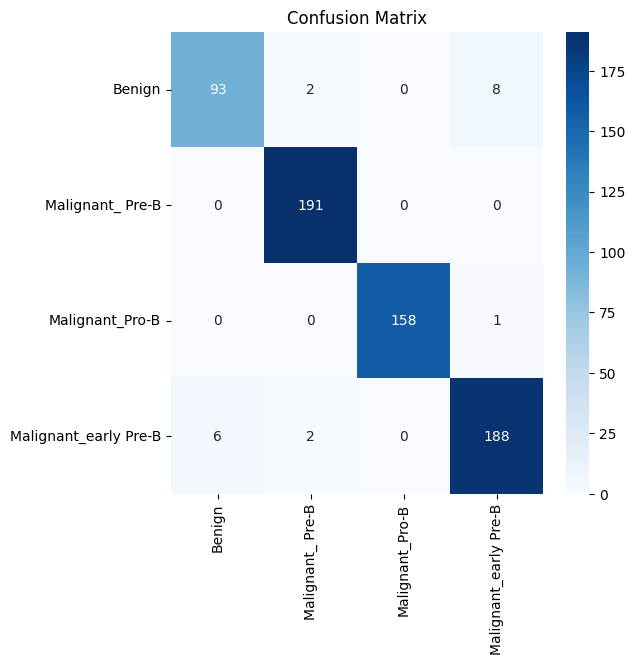

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import tensorflow as tf

# ==========================
# 1. Setup Google Colab Environment
# ==========================
# Check if GPU is available
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Device:", tf.test.gpu_device_name())

# Path to the dataset (adjust to where your data is on Google Drive)
root_input = "/content/drive/My Drive/datasets"
data_dir = "/content/dataset/ALL_dataset1/Blood cell Cancer _ALL"

if not os.path.exists(data_dir):
    print("❌ Dataset path not found. Available folders are:")
    print(os.listdir(root_input))
    raise FileNotFoundError("Please check your dataset path!")

# ==========================
# 2. Setup model saving directory
# ==========================
save_dir = "/content/drive/My Drive/EfficientNetB3_ALL1_models"
os.makedirs(save_dir, exist_ok=True)
checkpoint_path = f"{save_dir}/EfficientNetB3_best.keras"

# ==========================
# 3. Build DataFrame
# ==========================
classes = [c for c in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, c))]
classes = sorted(classes)

all_images, all_labels = [], []
for cls in classes:
    cls_folder = os.path.join(data_dir, cls)
    for img_file in os.listdir(cls_folder):
        if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(cls_folder, img_file))
            all_labels.append(cls)

df = pd.DataFrame({'filepath': all_images, 'label': all_labels})
label2idx = {cls: i for i, cls in enumerate(classes)}
df['label_idx'] = df['label'].map(label2idx)

print(f"✅ Found {len(classes)} classes: {classes}")
print(f"✅ Total images: {len(df)}")

# ==========================
# 4. Train/Val Split
# ==========================
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label_idx'], random_state=42)

# ==========================
# 5. Data Generators
# ==========================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import efficientnet

preprocess_fn = efficientnet.preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_fn,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(224,224), class_mode='categorical',
    batch_size=32, shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(224,224), class_mode='categorical',
    batch_size=32, shuffle=False
)

# ==========================
# 6. Mixed Precision (GPU boost)
# ==========================
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ==========================
# 7. Model: Resume if checkpoint exists
# ==========================
if os.path.exists(checkpoint_path):
    print("✅ Found checkpoint, resuming training...")
    model = tf.keras.models.load_model(checkpoint_path)
else:
    print("⚠️ No checkpoint found, building new model...")
    base_model = tf.keras.applications.EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base_model.trainable = False

    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    output = tf.keras.layers.Dense(len(classes), activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(base_model.input, output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ==========================
# 8. Callbacks
# ==========================
from sklearn.metrics import classification_report, confusion_matrix
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path, monitor='val_accuracy',
    save_best_only=True, verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# ==========================
# 9. Train with GPU
# ==========================
with tf.device("/GPU:0"):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        callbacks=[checkpoint, early_stop],
        verbose=1
    )

# ==========================
# 10. Evaluation
# ==========================
y_pred = np.argmax(model.predict(val_gen), axis=1)
y_true = val_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
val_loss, val_acc = model.evaluate(val_gen)
print(f"Validation Accuracy: {val_acc:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 388ms/step - accuracy: 0.9795 - loss: 0.0832
Validation Accuracy: 0.9707


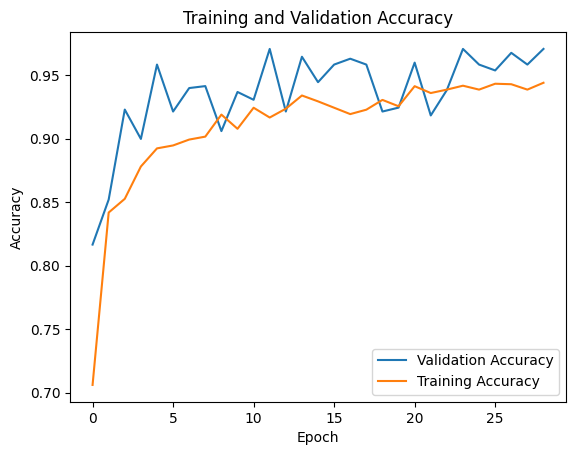

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()
